# Imports

In [1]:
from pathlib import Path
import shutil

from scipy.optimize import differential_evolution
import numpy as np
from scipy.spatial import cKDTree


import seaborn as sns
import ccdproc
import astropy.io.fits as fits

import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import astroalign as aa
import math
from astropy.io.fits import Header
import sep
import pandas as pd

import os
from dotenv import load_dotenv
from astroquery.astrometry_net import AstrometryNet
from astropy.io import fits

import read_mist_models
import numpy as np
from scipy.spatial import cKDTree

sns.set_theme()

astropy.__citation__

# Check Environment

Check if science and flat directories exist and are populated:

In [2]:
directory_names = ["science", "flats", "urat"]
project_root = Path.cwd()

for directory_name in directory_names:
    target_dir = project_root / "data" / directory_name
    if not target_dir.exists() or not target_dir.is_dir():
        raise RuntimeError(f"Directory {target_dir} does not exist")
    if not any(target_dir.iterdir()):
        raise RuntimeError(f"Directory {target_dir} contains no files")

Generate and clean necessary directories:

In [3]:
directory_names = ["flat-fielded", "aligned", "combined", "wcs", "masters", "cmd"]
project_root = Path.cwd()

for directory_name in directory_names:
    target_dir = project_root / "generated" / directory_name
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True)

# Helpers

In [4]:
def get_v_min_max(*fits_data):
    return min(np.percentile(data.data - data.mean(), 5) for data in fits_data), max(
        np.percentile(data.data - data.mean(), 95) for data in fits_data)

In [5]:
def plot_fits(fits_data, titles, cbar_label):
    n = len(fits_data)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), constrained_layout=True)

    if n == 1:
        axes = [axes]

    processed = [fd - fd.mean() for fd in fits_data]
    vmin, vmax = get_v_min_max(*processed)

    for ax, data, title in zip(axes, processed, titles):
        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap='magma')
        ax.set_title(title)

    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.04, pad=0.02)
    cbar.set_label(cbar_label)
    # plt.show()

# Combine flats

Combine helper function:

In [6]:
def combine_flats(filenames, save_name):
    images = []
    for f in filenames:
        hdr = fits.getheader(f)
        data = fits.getdata(f) + 1.0 * hdr['PEDESTAL']
        data /= data.mean()
        images.append(ccdproc.CCDData(data, unit=u.adu))

        flat = ccdproc.combine(images, method='average')
    fits.writeto(f'./generated/masters/{save_name}.fits', flat.data, overwrite=True)
    return flat.data

Combine V and r flats:

In [7]:
flat_V = combine_flats(filenames=['./data/flats/flat%dV.FIT' % j for j in range(1, 11)], save_name="masterFlatV")
flat_r = combine_flats(filenames=['./data/flats/flat%dr.FIT' % j for j in range(1, 11)], save_name="masterFlatr")

Assert correct normalisation:

In [8]:
assert flat_V.mean() == 1.0, "V master flat is not normalised!"
assert flat_r.mean() == 1.0, "r master flat is not normalised!"

Plot results:

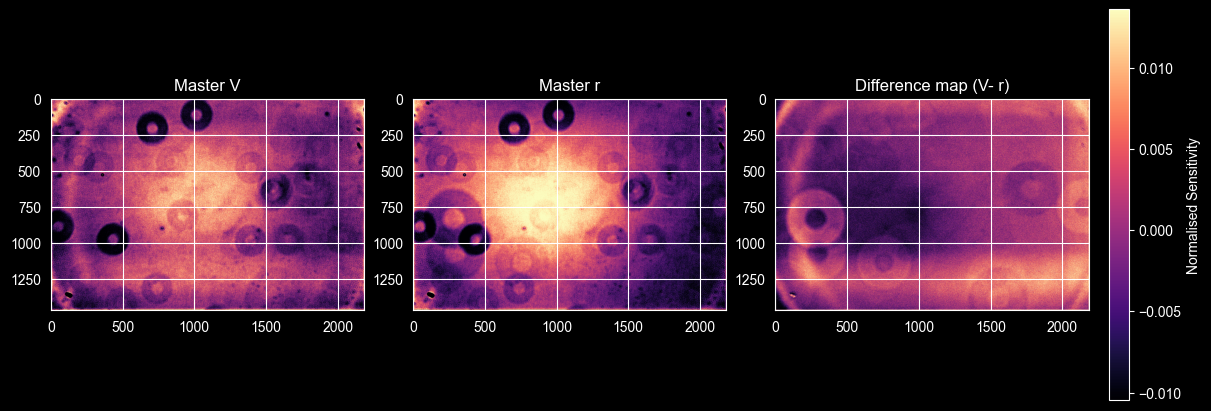

In [9]:
    plot_fits([flat_V, flat_r, flat_V - flat_r], ["Master V", "Master r", "Difference map (V- r)"], "Normalised Sensitivity")

Sensitivity variation analysis:

In [10]:
print("Sensitivity variation analysis:")
print(f"FlatV max: {np.max(flat_V.data) - np.min(flat_V.data)} | std dev: {np.std(flat_V.data)} ")
print(f"Flatr max: {np.max(flat_r.data) - np.min(flat_r.data)} | std dev: {np.std(flat_r.data)} ")

Sensitivity variation analysis:
FlatV max: 0.4901246409743598 | std dev: 0.0071324725432577105 
Flatr max: 0.35615248635490504 | std dev: 0.009080286588052837 


# Make Flat Fielded

Make helper function:

In [11]:
def make_flat_fielded(suffix, master_flat):
    for j in range(1, 11):
        file_in = f"./data/science/science{j}{suffix}.FIT"
        file_out = f"./generated/flat-fielded/science{j}{suffix}f.fits"
        print("Processing file: %s -> %s" % (file_in, file_out))

        hdr = fits.getheader(file_in)
        data = fits.getdata(file_in) + 1.0 * hdr['PEDESTAL']

        data /= master_flat

        hdr.add_comment("Pedestal corrected")
        hdr.add_comment("Flat-fielded with master_flat")
        hdr.add_comment("Saved as 32-bit integer")

        fits.writeto(file_out, np.int32(data), hdr, overwrite=True)

Make flat fielded:

In [12]:
make_flat_fielded("V", fits.getdata("./generated/masters/masterFlatV.fits"))
make_flat_fielded("r", fits.getdata("./generated/masters/masterFlatr.fits"))


Processing file: ./data/science/science1V.FIT -> ./generated/flat-fielded/science1Vf.fits
Processing file: ./data/science/science2V.FIT -> ./generated/flat-fielded/science2Vf.fits
Processing file: ./data/science/science3V.FIT -> ./generated/flat-fielded/science3Vf.fits
Processing file: ./data/science/science4V.FIT -> ./generated/flat-fielded/science4Vf.fits
Processing file: ./data/science/science5V.FIT -> ./generated/flat-fielded/science5Vf.fits
Processing file: ./data/science/science6V.FIT -> ./generated/flat-fielded/science6Vf.fits
Processing file: ./data/science/science7V.FIT -> ./generated/flat-fielded/science7Vf.fits
Processing file: ./data/science/science8V.FIT -> ./generated/flat-fielded/science8Vf.fits
Processing file: ./data/science/science9V.FIT -> ./generated/flat-fielded/science9Vf.fits
Processing file: ./data/science/science10V.FIT -> ./generated/flat-fielded/science10Vf.fits
Processing file: ./data/science/science1r.FIT -> ./generated/flat-fielded/science1rf.fits
Processi

Plot results:

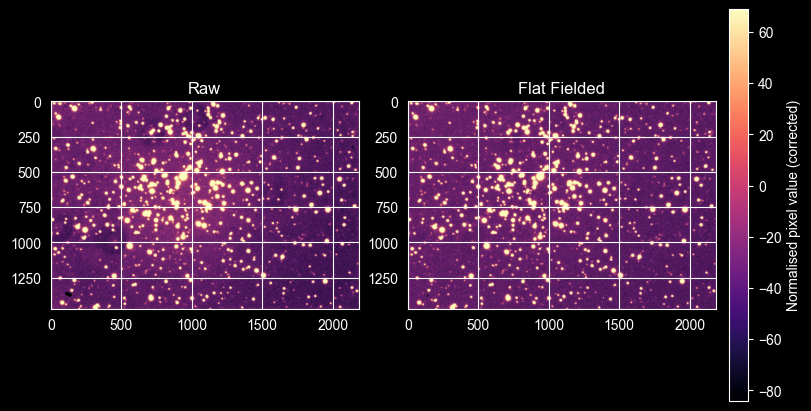

In [13]:
INDEX = 3
raw = fits.getdata(f"./data/science/science{INDEX}r.FIT")
flat_fielded = fits.getdata(f"./generated/flat-fielded/science{INDEX}rf.fits")
plot_fits([raw, flat_fielded], ["Raw", "Flat Fielded"], "Normalised pixel value (corrected)")

# Align

Define helper function:

In [14]:

# Read target image
def align(suffix, datatarg):
    fits.writeto(f"./generated/aligned/science1{suffix}t.fits", datatarg, overwrite=True)

    for j in range(2, 11):
        file_in = f"./generated/flat-fielded/science{j}{suffix}.fits"
        file_out = f"./generated/aligned/science{j}{suffix}t.fits"

        datasrc = fits.getdata(file_in)

        T, (source_pos_array, target_pos_array) = aa.find_transform(datasrc, datatarg)
        print(f"Image name = {file_in}  shifts= {T.translation} rot= {T.rotation * 180 / math.pi}  scale = {T.scale}")

        assert abs(T.rotation * 180 / math.pi) < 0.01, "Rotation deviates too much!"
        assert abs(T.scale - 1) < 0.0002, "Scale deviates too much!"

        data_tran, footprint = aa.apply_transform(T, datasrc, datatarg)
        fits.writeto(file_out, data_tran, overwrite=True)


Align images:

In [15]:
datatarg = fits.getdata(f'./generated/flat-fielded/science1Vf.fits')
align("Vf", datatarg)
align("rf", datatarg)

Image name = ./generated/flat-fielded/science2Vf.fits  shifts= [-0.6177937   1.65201819] rot= -0.0012524002308583503  scale = 1.000078656417958
Image name = ./generated/flat-fielded/science3Vf.fits  shifts= [-2.12211109  2.10279622] rot= 0.0015954975785294867  scale = 0.9999849730161242
Image name = ./generated/flat-fielded/science4Vf.fits  shifts= [-2.61447818  3.07290393] rot= -0.00046059895705181394  scale = 0.9999922606565693
Image name = ./generated/flat-fielded/science5Vf.fits  shifts= [-2.7413116   3.57883064] rot= -0.0016040846527379372  scale = 1.000023970611019
Image name = ./generated/flat-fielded/science6Vf.fits  shifts= [-3.29105507  4.28391811] rot= -0.001260662524501236  scale = 0.9999825927178166
Image name = ./generated/flat-fielded/science7Vf.fits  shifts= [-3.77500249  4.2204149 ] rot= -0.0010740807404597678  scale = 0.9999958875307577
Image name = ./generated/flat-fielded/science8Vf.fits  shifts= [-4.20368585  5.05399074] rot= -0.0012171937307103474  scale = 0.99999

# Combine

Helper function for combining:

In [16]:
def combine_aligned(suffix):
    filenames = [f"./generated/aligned/science{j}{suffix}ft.fits" for j in range(1, 11)]
    images = [ccdproc.CCDData(fits.getdata(f), unit=u.adu) for f in filenames]
    sciAvg = ccdproc.combine(images, method='average')

    header = Header(sciAvg.meta)

    # Save the output
    fits.writeto(f'./generated/combined/{suffix}cmb.fits', sciAvg.data, header, overwrite=True)


Combine:

In [17]:
combine_aligned("V")
combine_aligned("r")

Plot results:

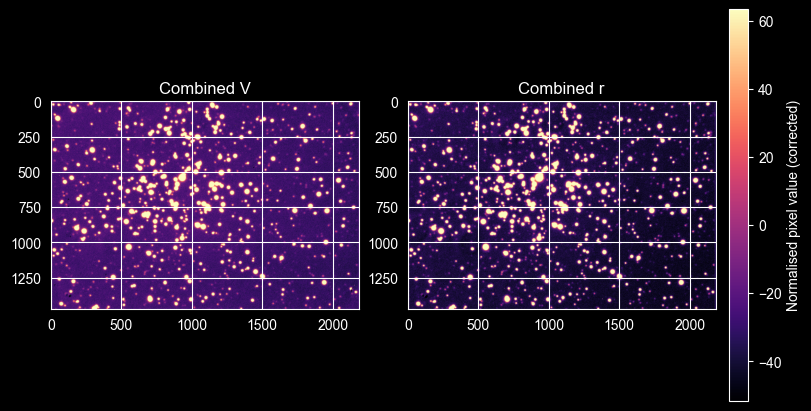

In [18]:
combinedV = fits.getdata(f"./generated/combined/Vcmb.fits")
combinedr = fits.getdata(f"./generated/combined/rcmb.fits")
plot_fits([combinedV, combinedr], ["Combined V", "Combined r"], "Normalised pixel value (corrected)")

# World Coordinate System

Helpers:

In [19]:
load_dotenv()
ASTROMETRY_KEY = os.getenv('ASTROMETRY_KEY')

def add_wcs_online(input_fits, output_fits):
    ast = AstrometryNet()
    ast.api_key = ASTROMETRY_KEY

    with fits.open(input_fits) as hdul:
        header = hdul[0].header
        data = hdul[0].data

        wcs_header = ast.solve_from_image(
            input_fits,
            solve_timeout=300
        )

        if wcs_header is None:
            raise RuntimeError("Astrometry solution failed.")

        header.update(wcs_header)

        fits.writeto(output_fits, data, header, overwrite=True)

Add WCS:

In [20]:
print("Start V solving")
add_wcs_online("./generated/combined/Vcmb.fits", "./generated/wcs/Vmaster.fits")
print()
print("Start r solving")
add_wcs_online("./generated/combined/rcmb.fits", "./generated/wcs/rmaster.fits")
print("Done!")

Start V solving
Solving.........
Start r solving
Solving..........Done!


# Extract Background

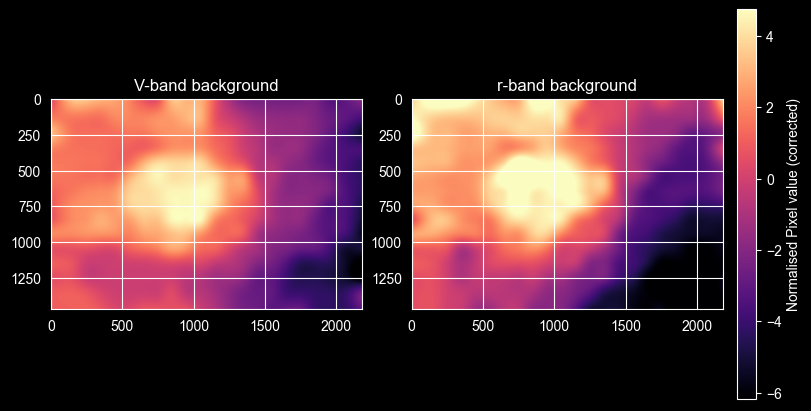

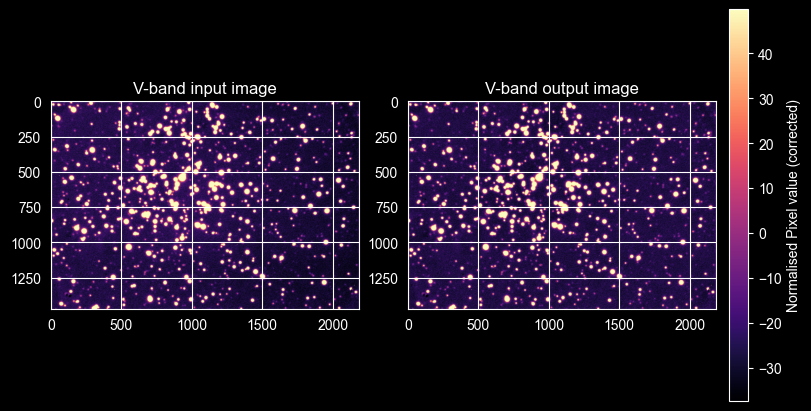

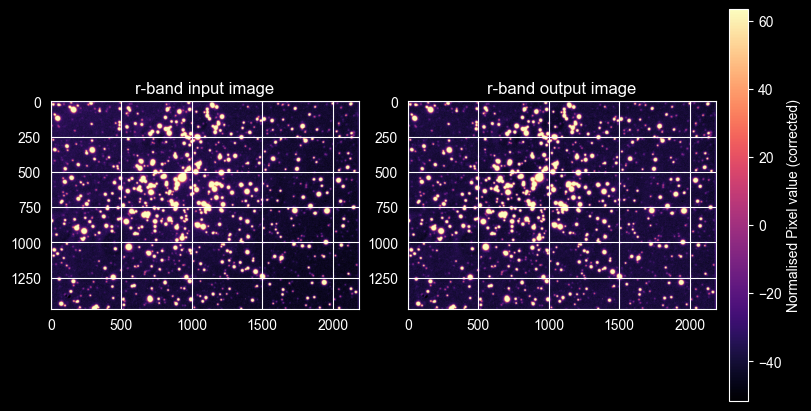

In [21]:
# Load the images
Vdat = fits.getdata('./generated/wcs/Vmaster.fits') # !!!!!!!Need to add wcs
rdat = fits.getdata('./generated/wcs/rmaster.fits') # !!!!!!!Need to add wcs

# # Swap around the byte order (RAISES!!!!)
# srdat = rdat.byteswap().newbyteorder()
# sVdat = Vdat.byteswap().newbyteorder()

srdat = np.array(rdat, dtype=np.float32)
sVdat = np.array(Vdat, dtype=np.float32)

# Define the background model
bw, bh = 100, 100  # Sizes of background boxes
fw, fh = 3, 3  # Number of background boxes
rbkg = sep.Background(srdat, bw=bw, bh=bh, fw=fw, fh=fh)
Vbkg = sep.Background(sVdat, bw=bw, bh=bh, fw=fw, fh=fh)

# Subtract the background
r_data_sub = srdat - rbkg.back()
V_data_sub = sVdat - Vbkg.back()

plot_fits([Vbkg.back(), rbkg.back()], ["V-band background", "r-band background"], "Normalised Pixel value (corrected)")
plot_fits([sVdat, V_data_sub], ["V-band input image", "V-band output image"], "Normalised Pixel value (corrected)")
plot_fits([srdat, r_data_sub], ["r-band input image", "r-band output image"], "Normalised Pixel value (corrected)")


# Extract Sources

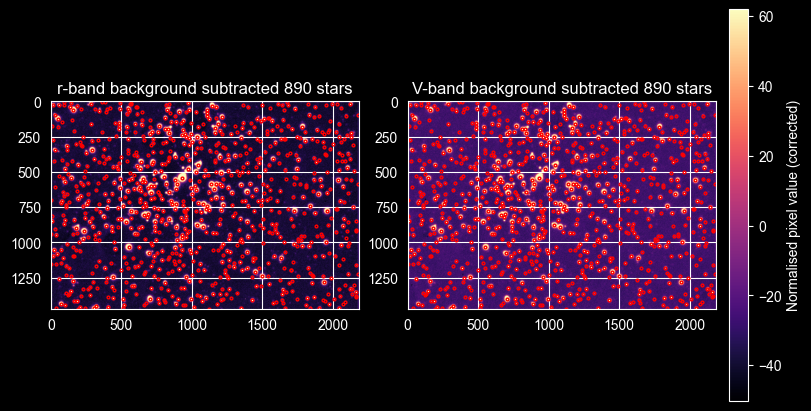

In [22]:
# Now extract the sources from the background-subtracted V-band image
objects = sep.extract(V_data_sub, 1.5, minarea=5, err=Vbkg.globalrms)

plot_fits([r_data_sub, V_data_sub], [f"r-band background subtracted {len(objects)} stars", f"V-band background subtracted {len(objects)} stars"], "Normalised pixel value (corrected)")

plt.subplot(1, 2, 1)
plt.plot(objects['x'], objects['y'], 'ro', markersize=2, markerfacecolor='None')

plt.subplot(1, 2, 2)
plt.plot(objects['x'], objects['y'], 'ro', markersize=2, markerfacecolor='None')

plt.show()


In [23]:
aper = 3.0
print('Aperture radius = %0.2f' % aper)
print('Based on a measured FWHM of %0.2f pixels' % 1)

Aperture radius = 3.00
Based on a measured FWHM of 1.00 pixels


# Magnitude Error Analysis

C:\Users\kdlee\AppData\Local\Temp\ipykernel_21780\3024986138.py:8: RuntimeWarning: invalid value encountered in log10
  rmag = -2.5 * np.log10(rflux)


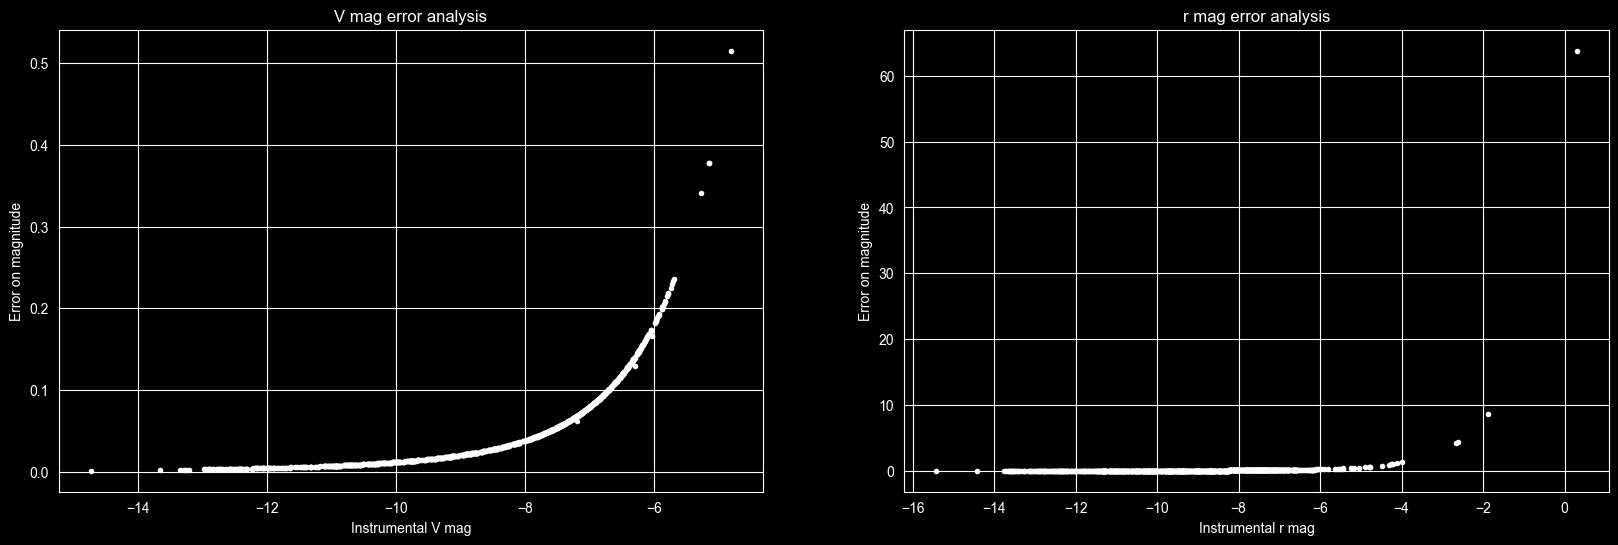

In [24]:
# Carry out aperture photometry
Vflux, Vfluxerr, Vflag = sep.sum_circle(V_data_sub, objects['x'], objects['y'], aper, err=Vbkg.globalrms, gain=1.0)
rflux, rfluxerr, rflag = sep.sum_circle(r_data_sub, objects['x'], objects['y'], aper, err=rbkg.globalrms, gain=1.0)

mask = (Vflux > 0) & (rflux > 0)

Vmag = -2.5 * np.log10(Vflux)
rmag = -2.5 * np.log10(rflux)
Verr = 2.5/math.log(10)*Vfluxerr / Vflux
rerr = 2.5/math.log(10)*rfluxerr / rflux

plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plt.title("V mag error analysis")
plt.plot(Vmag, Verr, 'w.')
plt.xlabel('Instrumental V mag')
plt.ylabel('Error on magnitude')

plt.subplot(1, 2, 2)
plt.title("r mag error analysis")
plt.plot(rmag, rerr, 'w.')
plt.xlabel('Instrumental r mag')
plt.ylabel('Error on magnitude')

plt.show()


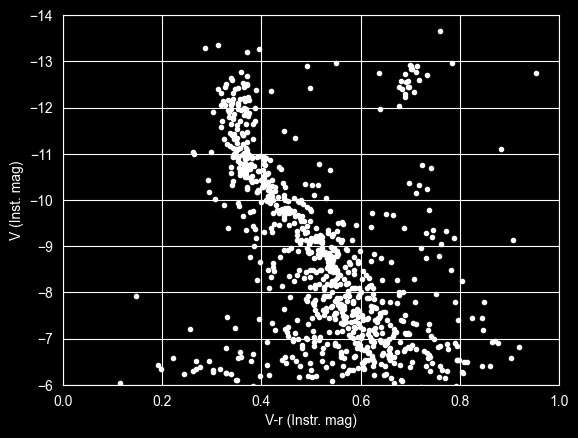

In [25]:
plt.plot(Vmag - rmag, Vmag, 'w.')
plt.xlabel("V-r (Instr. mag)")
plt.ylabel("V (Inst. mag)")
plt.ylim(-6, -14)
plt.xlim(0, 1)
plt.show()

# Zero Points

Text(0, 0.5, 'Declination [deg]')

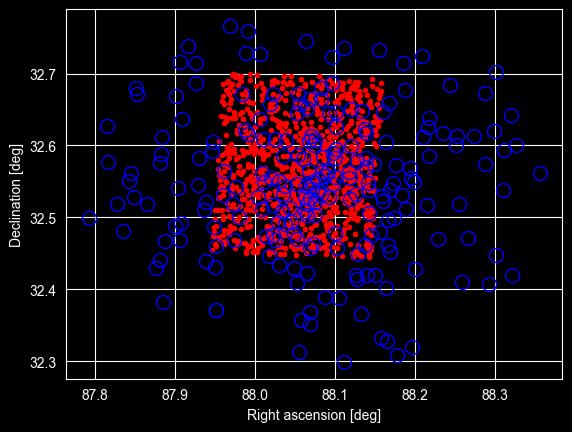

In [26]:
# Now read the WCS information from the image header

from astropy.wcs import WCS
wcs = WCS('./generated/wcs/Vmaster.fits')

ra, de = wcs.all_pix2world(objects['x'], objects['y'], 0)
hdu = fits.open("./data/urat/asu.fit")

plt.plot(ra, de, 'r.')
plt.plot(hdu[1].data['RAICRS'], hdu[1].data['DEICRS'], 'b.', markersize=20, markerfacecolor='None')
plt.xlabel('Right ascension [deg]')
plt.ylabel('Declination [deg]')

Match:

In [27]:
# This small piece of code matches each entry in the URAT1 catalogue
# with a corresponding SourceExtractor measurement

r1,V1,r2,V2 = [], [], [], []
er1,eV1, er2, eV2 = [], [], [], []

# Loop through the URAT1 catalogue
for _rai, _dei, _Vi, _ri, _eVi, _eri in zip(hdu[1].data['RAICRS'],
                                hdu[1].data['DEICRS'],
                                hdu[1].data['Vmag'],
                                hdu[1].data['rmag'],
                                hdu[1].data['e_Vmag'],
                                hdu[1].data['e_rmag']):

    # Compute the distance to each SourceExtractor source and find
    # the best match (smallest distance)
    dsq = (np.cos(_dei*math.pi/180)*(_rai-ra))**2 + (_dei-de)**2
    imin = np.argmin(dsq)
    dmin = (dsq[imin]**0.5)*3600

    # If there is a match within 1 arcsec that has both a
    # V- and r- band measurement in URAT1:

    if (dmin < 1 and _ri > 0 and _Vi > 0):
        r1.append(_ri)     # r and V magnitudes from URAT
        V1.append(_Vi)
        er1.append(_eri)   # and their uncertainties
        eV1.append(_eVi)

        r2.append(rmag[imin]) # r and V magnitudes from SourceExtractor
        V2.append(Vmag[imin])
        er2.append(rerr[imin]) # and their uncertainties
        eV2.append(Verr[imin])


r1 = np.array(r1)  # Convert to numpy arrays
V1 = np.array(V1)
er1 = np.array(er1)
eV1 = np.array(eV1)

r2 = np.array(r2)
V2 = np.array(V2)
er2 = np.array(er2)
eV2 = np.array(eV2)

Errors on V:

V zero-point = 23.880 mag


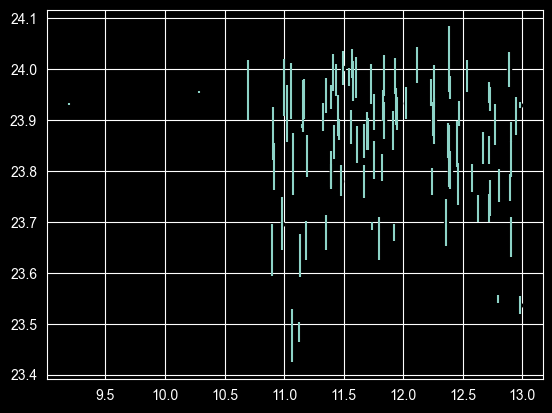

In [28]:
plt.plot(V1, V1-V2,'k.')
plt.errorbar(V1, V1-V2, yerr=(er1**2 + er2**2)**0.5, linestyle='None')
dV = np.median(V1-V2)
print('V zero-point = %0.3f mag' % dV)

Errors on r:

r zero-point = 24.172 mag


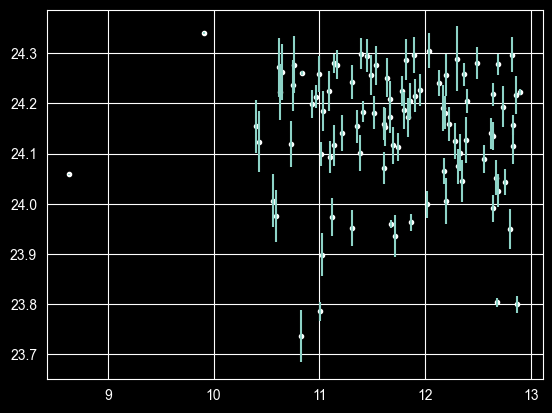

In [29]:
plt.plot(r1, r1-r2,'w.')
plt.errorbar(r1, r1-r2, yerr=(er1**2 + er2**2)**0.5, linestyle='None')
dr = np.median(r1-r2)
print('r zero-point = %0.3f mag' % dr)

Apply Zero Points:

Text(0.5, 1.0, 'M37: Calibrated CMD')

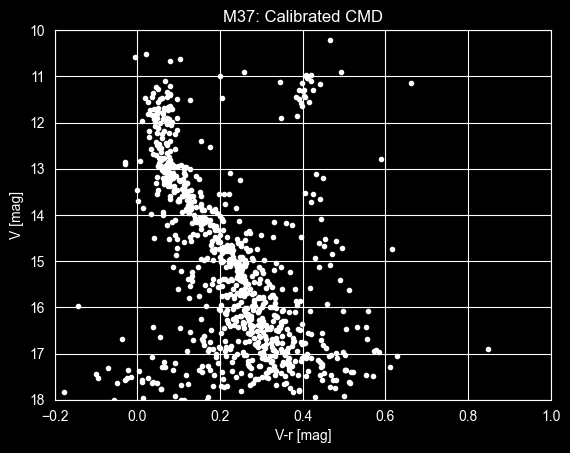

In [30]:
Vcal = Vmag + dV
rcal = rmag + dr
plt.plot(Vcal-rcal, Vcal, 'w.')
plt.xlim(-0.20,1)
plt.ylim(18,10)
plt.xlabel('V-r [mag]')
plt.ylabel('V [mag]')
plt.minorticks_on()
plt.title('M37: Calibrated CMD')

Save:

In [31]:
w = np.where(~np.isnan(rcal))
np.savetxt('./generated/cmd/cmd.txt', np.transpose([Vcal[w],Verr[w],rcal[w],rerr[w]]), fmt="%6.3f %6.3f %6.3f %6.3f")

# Photometry

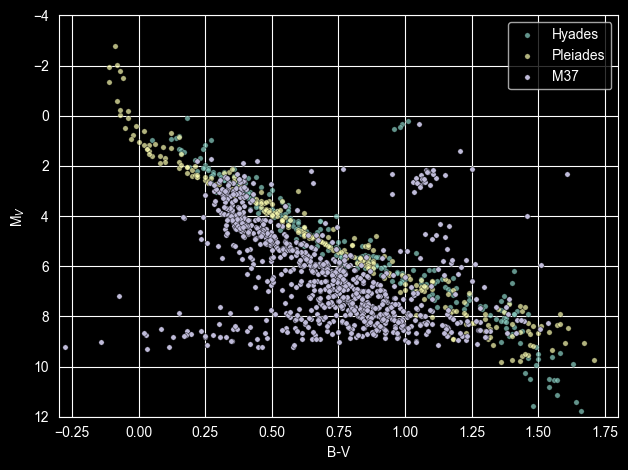

In [32]:
M37_data = np.loadtxt("./generated/cmd/cmd.txt")
MVH, BVH = np.loadtxt('./data/photometry/Hyades.txt', usecols=(1,2), unpack=True)
MVP, BVP = np.loadtxt('./data/photometry/Pleiades.txt', usecols=(1,2), unpack=True)

M37_V, M37_r = M37_data[:, 0], M37_data[:, 2]
M37_BV = (M37_V - M37_r + 0.11) / 0.48


M37_M_V = M37_V - 8.8

sns.scatterplot(x=BVH, y=MVH, s=15, color="C0", edgecolor="black", label="Hyades", alpha=0.7)
sns.scatterplot(x=BVP, y=MVP, s=15, color="C1", edgecolor="black",label="Pleiades", alpha=0.7)
sns.scatterplot(x=M37_BV, y=M37_M_V, s=15, color="C2", edgecolor="black", label="M37", alpha=1)

plt.legend(frameon=True)
plt.xlim(-0.3, 1.8)
plt.ylim(12,-4)
plt.xlabel('B-V')
plt.ylabel(r'M$_V$')
plt.minorticks_on()
plt.tight_layout()
plt.show()

In [42]:
file_path = './data/isochrones/isochrones.dat'

with open(file_path) as f:
    for line in f:
        if line.startswith('# Zini'):
            columns = line[1:].strip().split()
            break

df = pd.read_csv(
    file_path,
    sep=r'\s+',
    comment='#',
    names=columns
)

In [141]:
x_data = M37_V - M37_r
y_data = M37_V

x_scale = 1
y_scale = 1

# Error function stays the same
def isochrone_error(params):
    log_age, mu = params

    nearest_age = available_ages[np.argmin(np.abs(available_ages - log_age))]

    iso = df[
        (df['logAge_round'] == nearest_age) &
        (df['label'] <= 5)
    ]

    if len(iso) == 0:
        return np.inf

    x_iso = iso["Vmag"].values - iso["Rmag"].values
    y_iso = iso["Vmag"].values + mu

    x_iso_scaled = x_iso / x_scale
    y_iso_scaled = y_iso / y_scale

    data_scaled = np.vstack((x_data / x_scale, y_data / y_scale)).T
    iso_scaled = np.vstack((x_iso_scaled, y_iso_scaled)).T

    tree = cKDTree(iso_scaled)
    distances, _ = tree.query(data_scaled)

    low, high = np.percentile(distances, [20, 80])
    mask = (distances >= low) & (distances <= high)

    return np.mean(distances[mask]**2)

In [142]:

bounds = [
    (available_ages.min(), available_ages.max()),  # log_age bounds
    (8.0, 15.0)                                    # reasonable mu bounds
]

result = differential_evolution(
    isochrone_error,
    bounds,
    strategy='best1bin',
    maxiter=100,
    polish=True
)

best_log_age, best_mu = result.x

# Convert age
age_years = 10**best_log_age
age_myr = age_years / 1e6

# Convert distance
distance_pc = 10**((best_mu + 5) / 5)
distance_ly = distance_pc * 3.26156

print("\nBest fit:")
print(f"log_age = {best_log_age:.4f}")
print(f"mu = {best_mu:.4f}")
print(f"Age = {age_myr:.2f} Myr")
print(f"Distance = {distance_ly:.0f} lightyears")
print(f"error = {result.fun:.6f}")


Best fit:
log_age = 8.6431
mu = 11.9302
Age = 439.60 Myr
Distance = 7934 lightyears
error = 0.010252


In [86]:
# print(phase)

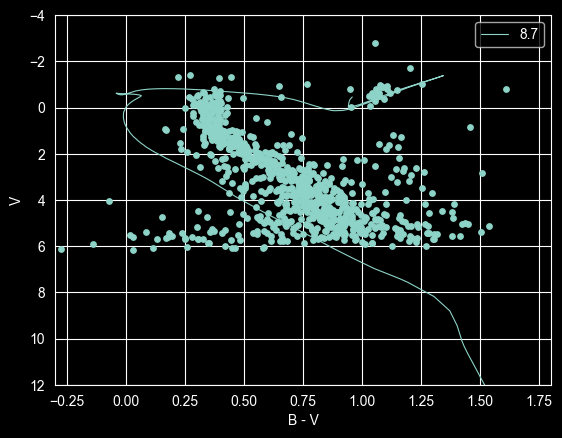

In [139]:
plt.figure()

# for age in ages[::4]:
#     iso = df[(df['logAge'] == age) & (df['label'] <= 5)]
#     plt.plot(iso['Bmag'] - iso['Vmag'], iso['Vmag'], linewidth=0.8, label=f"{age:.1f}")

nearest_age = available_ages[np.argmin(np.abs(available_ages - best_log_age))]

iso = df[
    (df['logAge_round'] == nearest_age) &
    (df['label'] <= 5)
]
plt.plot(iso['Bmag'] - iso['Vmag'], iso['Vmag'], linewidth=0.8, label=f"{log_age:.1f}")

plt.gca().invert_yaxis()
plt.scatter(M37_BV, M37_V - best_mu, s=15)
plt.xlabel('B - V')
plt.ylabel('V')
plt.xlim(-0.3, 1.8)
plt.ylim(12, -4)
plt.legend()
plt.show()

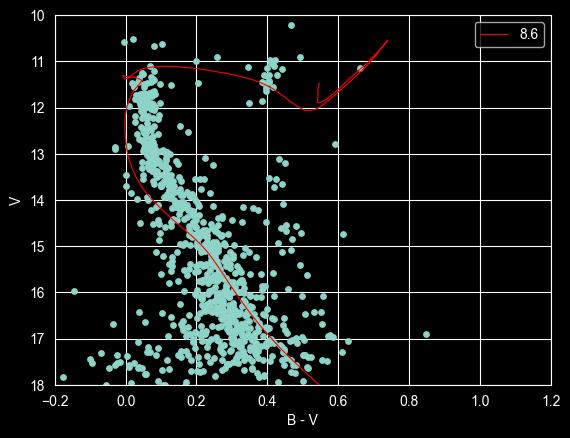

In [140]:
plt.figure()

# for age in ages[::4]:
#     iso = df[(df['logAge'] == age) & (df['label'] <= 5)]
#     plt.plot(iso['Bmag'] - iso['Vmag'], iso['Vmag'], linewidth=0.8, label=f"{age:.1f}")
nearest_age = available_ages[np.argmin(np.abs(available_ages - best_log_age))]

iso = df[
    (df['logAge_round'] == nearest_age) &
    (df['label'] <= 5)
]
plt.plot(iso['Vmag'] - iso['Rmag'], iso['Vmag'] + best_mu, linewidth=0.8, label=f"{best_log_age:.1f}", color="r")

plt.gca().invert_yaxis()
plt.scatter(M37_V - M37_r, M37_V, s=15)
plt.xlabel('B - V')
plt.ylabel('V')
plt.xlim(-0.2, 1.2)
plt.ylim(18, 10)
plt.legend()
plt.show()

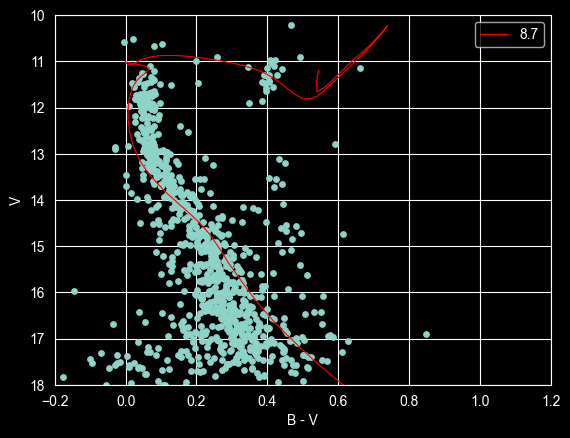

In [135]:
plt.figure()

best_mu = 11.5
best_log_age = 8.7
nearest_age = available_ages[np.argmin(np.abs(available_ages - best_log_age))]

iso = df[
    (df['logAge_round'] == nearest_age) &
    (df['label'] <= 5)
]
plt.plot(iso['Vmag'] - iso['Rmag'], iso['Vmag'] + best_mu, linewidth=0.8, label=f"{best_log_age:.1f}", color="r")

plt.gca().invert_yaxis()
plt.scatter(M37_V - M37_r, M37_V, s=15)
plt.xlabel('B - V')
plt.ylabel('V')
plt.xlim(-0.2, 1.2)
plt.ylim(18, 10)
plt.legend()
plt.show()

In [136]:
age_years = 10**best_log_age
age_myr = age_years / 1e6

# Convert distance
distance_pc = 10**((best_mu + 5) / 5)
distance_ly = distance_pc * 3.26156

print("\nBest fit:")
print(f"log_age = {best_log_age:.4f}")
print(f"mu = {best_mu:.4f}")
print(f"Age = {age_myr:.2f} Myr")
print(f"Distance = {distance_ly:.0f} lightyears")
print(f"error = {result.fun:.6f}")


Best fit:
log_age = 8.7000
mu = 11.5000
Age = 501.19 Myr
Distance = 6508 lightyears
error = 0.023284
